⚙️ PASO 1: Preparando Datos de Toda la Ciudad...
🧠 PASO 2: Generando memoria histórica...
🚀 PASO 3: Entrenando IA y calculando proyecciones 2026 (Esto puede tardar un minuto)...
✅ ¡Cálculo completado! Excel Maestro guardado como 'Prediccion_Completa_Barcelona_2026.xlsx'

📊 Generando Dashboard de ejemplo para Robos con Fuerza en Horta-Guinardó:


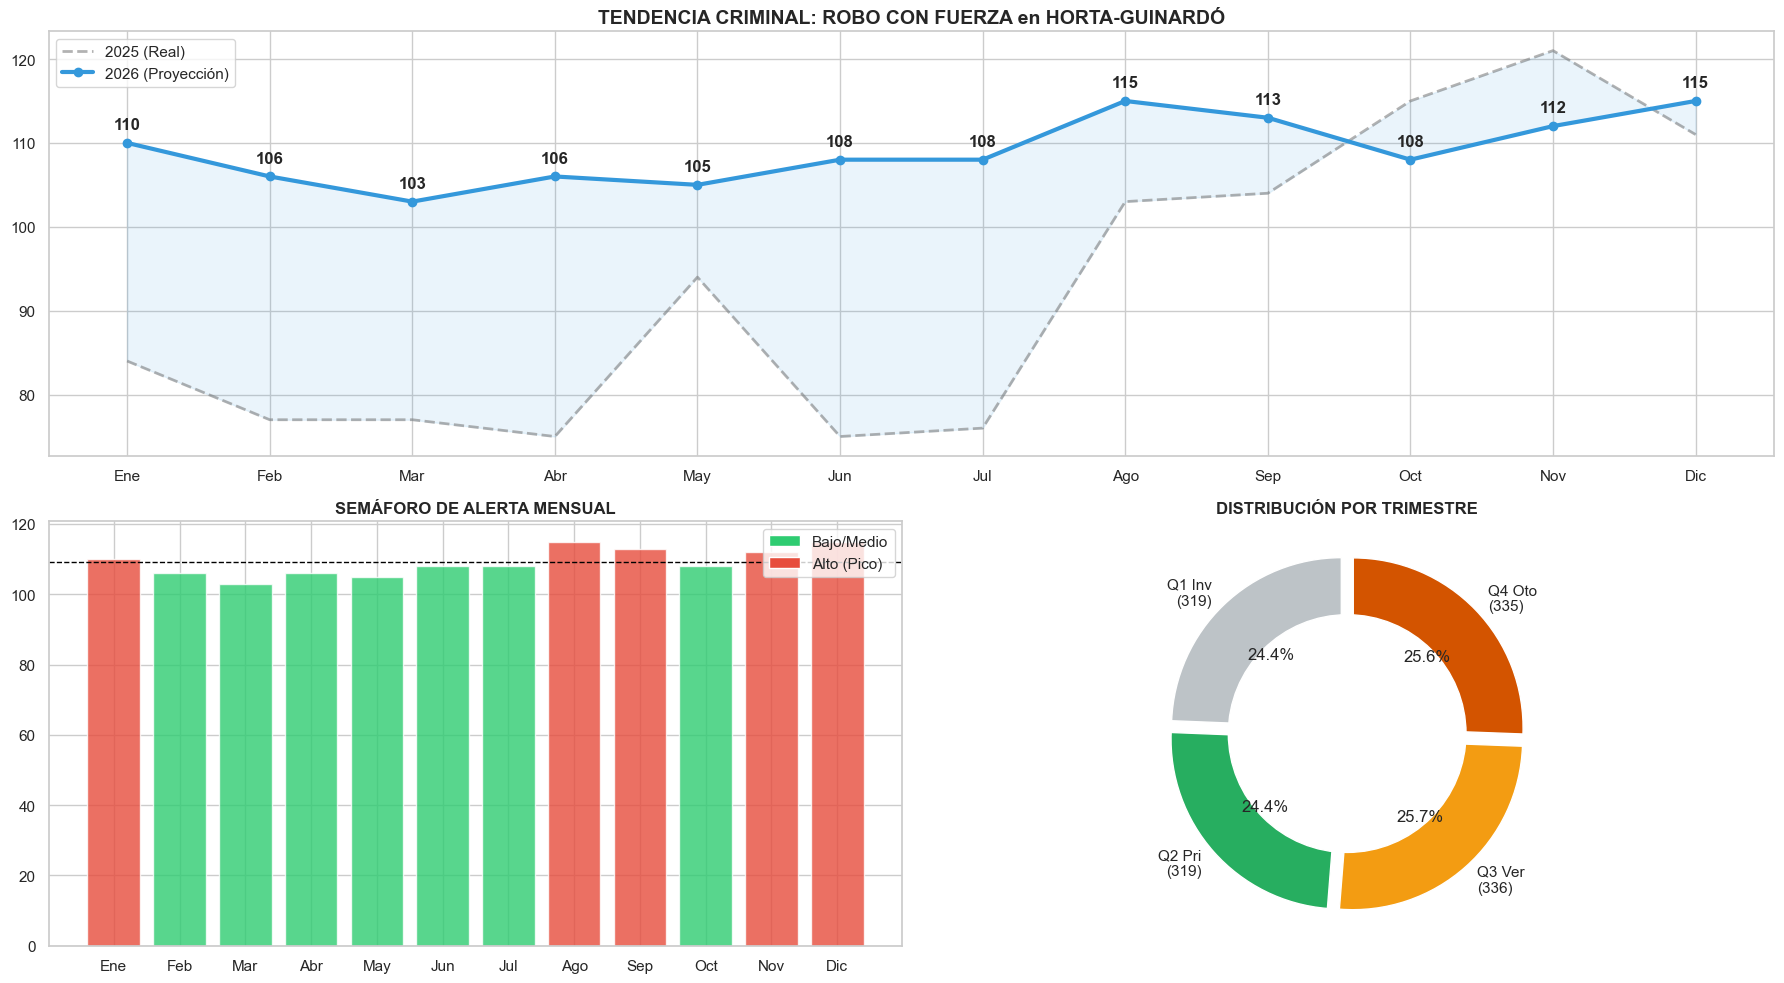

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore') # Ocultar avisos matemáticos menores

print("⚙️ PASO 1: Preparando Datos de Toda la Ciudad...")

# 1. Función de limpieza
def limpiar_socio(path, pivot_col):
    df = pd.read_csv(path)
    if 'Poblacion' in path:
        df.columns = [str(col).split()[-1] if '01 ene' in str(col).lower() else col for col in df.columns]
        df = df[df['Tipo de territorio'].isin(['Municipi', 'Districte'])]
    
    cols_num = [c for c in df.columns if c not in ['Territorio', 'Tipo de territorio', pivot_col]]
    for col in cols_num:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).str.replace('-', '0', regex=False).replace('', '0').astype(float)
    
    melted = df.melt(id_vars=['Territorio', 'Tipo de territorio', pivot_col], var_name='Año', value_name='Val')
    melted['Año'] = pd.to_numeric(melted['Año'], errors='coerce')
    return melted.pivot_table(index=['Territorio', 'Año'], columns=pivot_col, values='Val', aggfunc='first').reset_index()

# Carga de archivos
df_edad = limpiar_socio('Edad_Barrios.csv', 'Edad en grandes grupos')
df_pob = limpiar_socio('Poblacion-Inmigrante.csv', 'Nacionalidad (España/UE/Resto extranjero)')
df_crime = pd.read_csv('Criminalidad_Mensual_Estructurada.csv')

# Cruce
df_m = pd.merge(df_crime, df_edad, on=['Territorio', 'Año'], how='left')
df_m = pd.merge(df_m, df_pob, on=['Territorio', 'Año'], how='left')

# Reparar datos sociales (Forward Fill)
social_cols = ['16-64 años', '<16 años', '≥65 años', 'España', 'Resto del mundo']
df_m = df_m.sort_values(['Territorio', 'Categoría_Delito', 'Año', 'Mes_Num'])
df_m[social_cols] = df_m.groupby(['Territorio', 'Categoría_Delito'])[social_cols].ffill()
df_m = df_m.dropna(subset=social_cols).reset_index(drop=True)

# Crear Lags MASIVOS para toda la ciudad
print("🧠 PASO 2: Generando memoria histórica...")
for i in [1, 2, 3, 12]:
    df_m[f'Lag_{i}'] = df_m.groupby(['Territorio', 'Categoría_Delito'])['Cantidad'].shift(i)

# ==========================================
# 3. ENTRENAMIENTO Y PREDICCIÓN MASIVA
# ==========================================
print("🚀 PASO 3: Entrenando IA y calculando proyecciones 2026 (Esto puede tardar un minuto)...")

features = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_12', 'Mes_Num', '16-64 años', '<16 años', '≥65 años', 'España', 'Resto del mundo']
MAPA_MESES = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio', 
              7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}

resultados_totales = []
modelos_entrenados = {} # Guardaremos los modelos por si quieres usarlos después

distritos_unicos = df_m['Territorio'].unique()
delitos_unicos = df_m['Categoría_Delito'].unique()

for distrito in distritos_unicos:
    for delito in delitos_unicos:
        # Filtrar datos de entrenamiento (quitamos NaNs de los primeros 12 meses)
        data_train = df_m[(df_m['Territorio'] == distrito) & 
                          (df_m['Categoría_Delito'] == delito)].dropna().copy()
        
        # Solo entrenamos si hay historial suficiente
        if len(data_train) > 24:
            # Entrenar modelo
            rf = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42)
            rf.fit(data_train[features], data_train['Cantidad'])
            modelos_entrenados[f"{distrito}_{delito}"] = rf
            
            # Preparar predicción 2026
            historial = df_m[(df_m['Territorio'] == distrito) & (df_m['Categoría_Delito'] == delito) & (df_m['Año'] <= 2025)].sort_values(['Año', 'Mes_Num'])['Cantidad'].tolist()
            ultimo_ctx = data_train.iloc[-1]
            
            for mes in range(1, 13):
                feats = np.array([[historial[-1], historial[-2], historial[-3], historial[-12], mes,
                                   ultimo_ctx['16-64 años'], ultimo_ctx['<16 años'], ultimo_ctx['≥65 años'], 
                                   ultimo_ctx['España'], ultimo_ctx['Resto del mundo']]])
                
                pred = int(rf.predict(feats)[0])
                historial.append(pred)
                
                resultados_totales.append({
                    'Territorio': distrito,
                    'Categoría_Delito': delito,
                    'Año': 2026,
                    'Mes': MAPA_MESES[mes],
                    'Mes_Num': mes,
                    'Cantidad_Proyectada': pred
                })

# Guardar DataFrame Maestro
df_2026_master = pd.DataFrame(resultados_totales)
df_2026_master.to_excel('Prediccion_Completa_Barcelona_2026.xlsx', index=False)
print("✅ ¡Cálculo completado! Excel Maestro guardado como 'Prediccion_Completa_Barcelona_2026.xlsx'")

# ==========================================
# 4. FUNCIÓN DASHBOARD EJECUTIVO
# ==========================================
def mostrar_dashboard(distrito, delito):
    # Extraer proyecciones y datos reales
    proy = df_2026_master[(df_2026_master['Territorio'] == distrito) & 
                          (df_2026_master['Categoría_Delito'] == delito)].sort_values('Mes_Num')['Cantidad_Proyectada'].values
    
    real_2025 = df_m[(df_m['Territorio'] == distrito) & 
                     (df_m['Categoría_Delito'] == delito) & 
                     (df_m['Año'] == 2025)].sort_values('Mes_Num')['Cantidad'].values
    
    if len(proy) == 0:
        print(f"⚠️ No hay suficientes datos para {delito} en {distrito}.")
        return
        
    # Visualización
    sns.set_style("whitegrid")
    fig = plt.figure(figsize=(18, 10))
    gs = GridSpec(2, 2, figure=fig)
    meses_abbr = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    colores_meses = ['#2ecc71' if p < np.mean(proy) else '#e74c3c' for p in proy]

    # Panel 1: Tendencia
    ax1 = fig.add_subplot(gs[0, :])
    if len(real_2025) == 12:
        ax1.plot(meses_abbr, real_2025, label='2025 (Real)', color='gray', linestyle='--', alpha=0.6, linewidth=2)
        ax1.fill_between(meses_abbr, real_2025, proy, color='#3498db', alpha=0.1)
    ax1.plot(meses_abbr, proy, label='2026 (Proyección)', color='#3498db', marker='o', linewidth=3)
    ax1.set_title(f"TENDENCIA CRIMINAL: {delito.upper()} en {distrito.upper()}", fontsize=14, fontweight='bold')
    ax1.legend()
    for i, txt in enumerate(proy): ax1.annotate(f"{txt}", (i, proy[i]), xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

    # Panel 2: Semáforo
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.bar(meses_abbr, proy, color=colores_meses, alpha=0.8)
    ax2.axhline(np.mean(proy), color='black', linestyle='--', linewidth=1, label='Media Anual')
    ax2.set_title("SEMÁFORO DE ALERTA MENSUAL", fontsize=12, fontweight='bold')
    from matplotlib.patches import Patch
    ax2.legend(handles=[Patch(facecolor='#2ecc71', label='Bajo/Medio'), Patch(facecolor='#e74c3c', label='Alto (Pico)')], loc='upper right')

    # Panel 3: Trimestral
    ax3 = fig.add_subplot(gs[1, 1])
    trimestres = [sum(proy[0:3]), sum(proy[3:6]), sum(proy[6:9]), sum(proy[9:12])]
    labels = [f'Q1 Inv\n({trimestres[0]})', f'Q2 Pri\n({trimestres[1]})', f'Q3 Ver\n({trimestres[2]})', f'Q4 Oto\n({trimestres[3]})']
    ax3.pie(trimestres, labels=labels, colors=['#bdc3c7', '#27ae60', '#f39c12', '#d35400'], autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0.05, 0.05))
    ax3.add_artist(plt.Circle((0,0),0.70,fc='white'))
    ax3.set_title("DISTRIBUCIÓN POR TRIMESTRE", fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- EJEMPLO DE USO ---
print("\n📊 Generando Dashboard de ejemplo para Robos con Fuerza en Horta-Guinardó:")
mostrar_dashboard('Horta-Guinardó', 'Robo con fuerza')

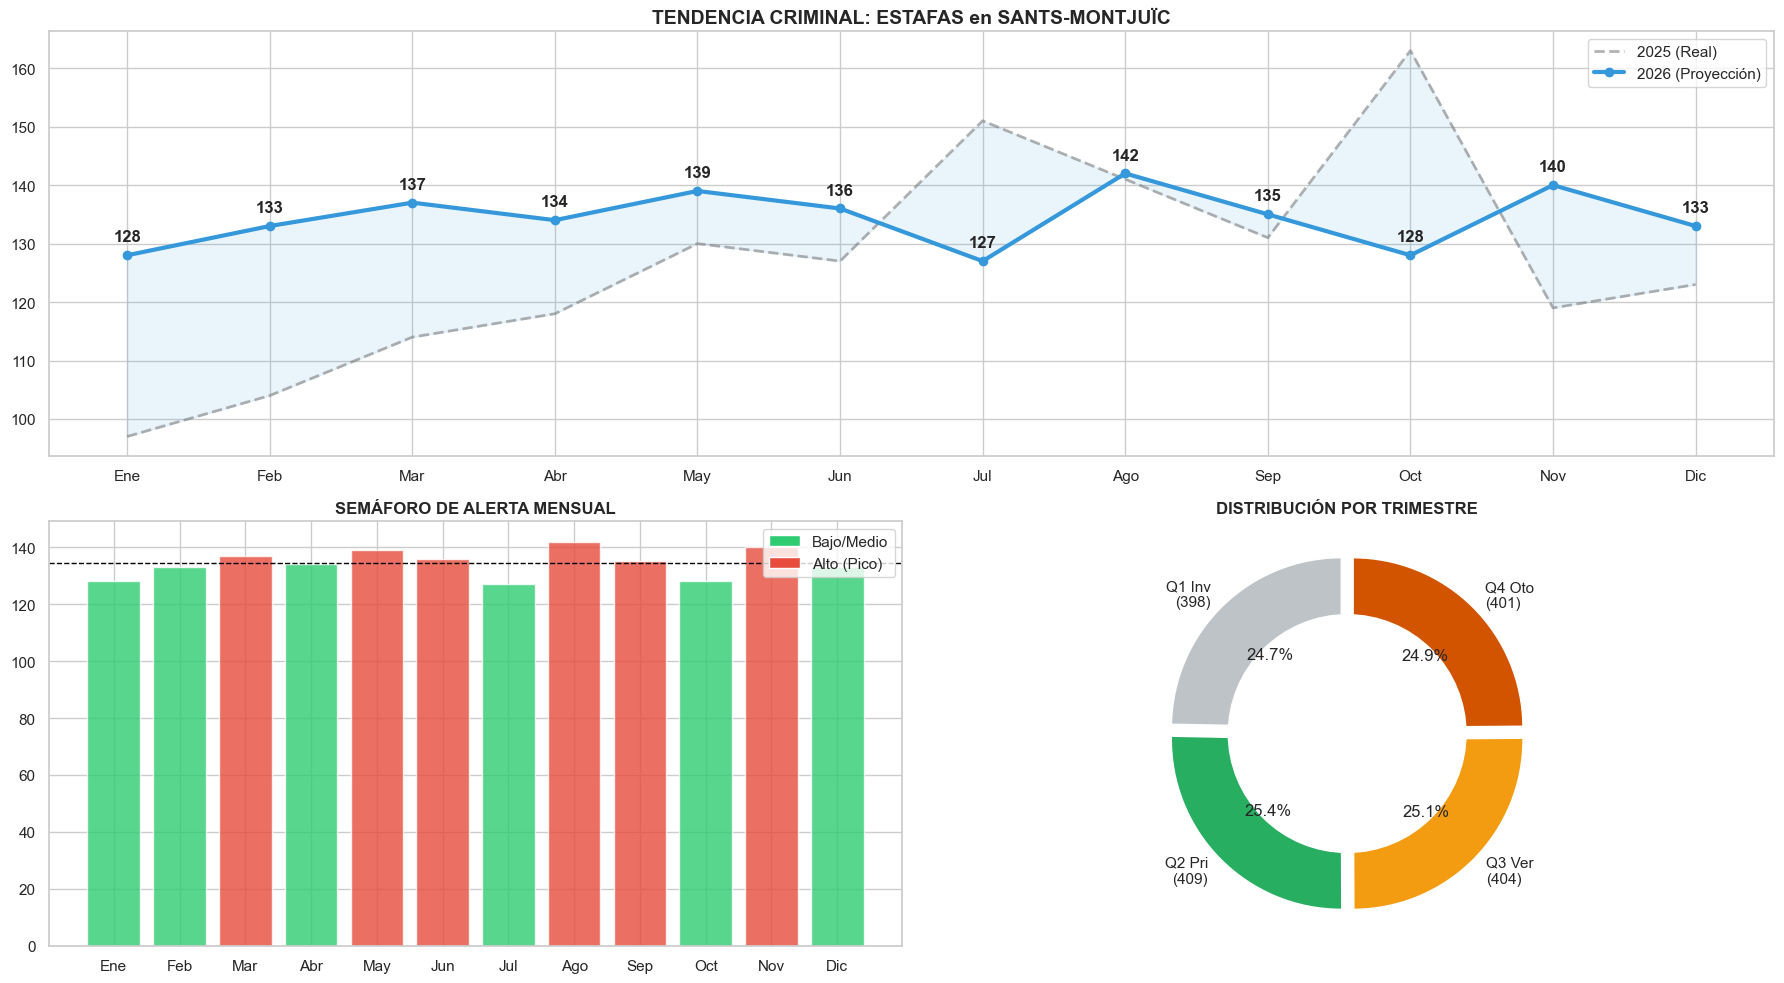

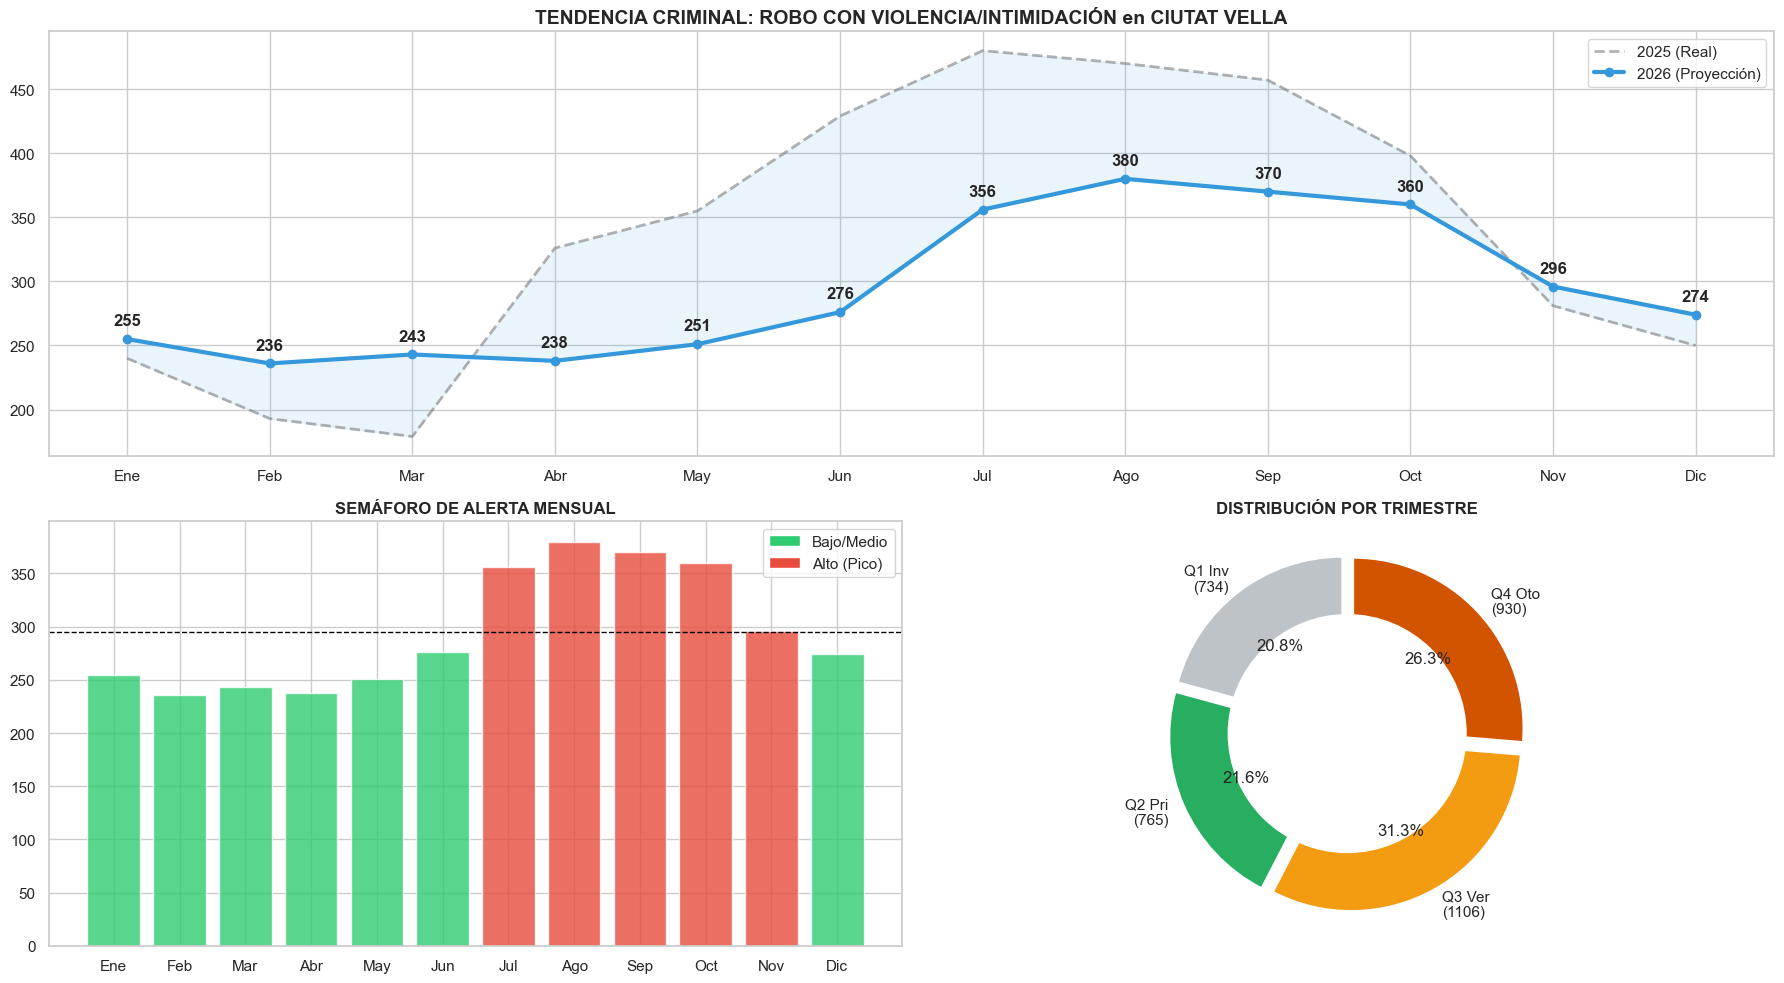

In [6]:
mostrar_dashboard('Sants-Montjuïc', 'Estafas')
mostrar_dashboard('Ciutat Vella', 'Robo con violencia/intimidación')

In [8]:
import pandas as pd
import folium
import numpy as np

print("🗺️ Preparando el Mapa Interactivo de Riesgo 2026...")

# 1. Cargar las proyecciones (el Excel Maestro que generamos antes)
df_proy = pd.read_excel('Prediccion_Completa_Barcelona_2026.xlsx')

# 2. Agrupaciones para el mapa
# A) Total por distrito (para el tamaño y color de la burbuja)
df_total = df_proy.groupby('Territorio')['Cantidad_Proyectada'].sum().reset_index()

# B) Top 3 delitos por distrito (para mostrar en el popup al hacer clic)
top_delitos_por_zona = df_proy.groupby(['Territorio', 'Categoría_Delito'])['Cantidad_Proyectada'].sum().reset_index()
top_delitos_por_zona = top_delitos_por_zona.sort_values(['Territorio', 'Cantidad_Proyectada'], ascending=[True, False])

# 3. Diccionario de Coordenadas
coordenadas_distritos = {
    'Ciutat Vella': [41.3828, 2.1769], 'Eixample': [41.3889, 2.1611],
    'Sants-Montjuïc': [41.3630, 2.1431], 'Les Corts': [41.3861, 2.1264],
    'Sarrià-Sant Gervasi': [41.4011, 2.1128], 'Gràcia': [41.4096, 2.1575],
    'Horta-Guinardó': [41.4283, 2.1561], 'Nou Barris': [41.4416, 2.1772],
    'Sant Andreu': [41.4358, 2.1897], 'Sant Martí': [41.4055, 2.1975]
}

# 4. Crear Mapa Base
mapa_bcn = folium.Map(location=[41.3950, 2.1600], zoom_start=12, tiles='cartodbpositron')

# Umbrales de riesgo
p33 = np.percentile(df_total['Cantidad_Proyectada'], 33)
p66 = np.percentile(df_total['Cantidad_Proyectada'], 66)

# 5. Dibujar las zonas interactivas
for index, row in df_total.iterrows():
    distrito = row['Territorio']
    total = int(row['Cantidad_Proyectada'])
    
    if distrito in coordenadas_distritos:
        lat, lon = coordenadas_distritos[distrito]
        
        # Lógica de Colores
        if total > p66:
            color, f_color = '#e74c3c', '#c0392b' # Rojo
        elif total > p33:
            color, f_color = '#f39c12', '#d35400' # Naranja
        else:
            color, f_color = '#2ecc71', '#27ae60' # Verde
            
        radio = np.sqrt(total) / 2
        
        # --- CREACIÓN DEL POPUP ENRIQUECIDO (HTML) ---
        # Extraemos los 4 delitos principales de este distrito específico
        delitos_zona = top_delitos_por_zona[top_delitos_por_zona['Territorio'] == distrito].head(4)
        
        # Construimos una tabla HTML en formato "string" para insertarla en el mapa
        html_popup = f"""
        <div style="font-family: Arial, sans-serif; width: 250px;">
            <h4 style="margin-bottom: 5px; color: {f_color};">{distrito.upper()}</h4>
            <p style="margin-top: 0px; font-size: 12px; color: gray;">
                <b>Total Previsto 2026:</b> {total} incidentes
            </p>
            <hr style="border-top: 1px solid #ccc;">
            <b style="font-size: 11px;">Top 4 Riesgos Principales:</b>
            <table style="width: 100%; font-size: 11px; margin-top: 5px;">
        """
        # Añadimos las filas de los delitos al HTML
        for _, d_row in delitos_zona.iterrows():
            nombre = d_row['Categoría_Delito'][:20] + "..." if len(d_row['Categoría_Delito']) > 20 else d_row['Categoría_Delito']
            cantidad = int(d_row['Cantidad_Proyectada'])
            html_popup += f"<tr><td style='padding: 2px;'>{nombre}</td><td style='text-align: right; font-weight: bold;'>{cantidad}</td></tr>"
            
        html_popup += "</table></div>"
        
        # Convertimos el string HTML a un objeto IFrame de Folium
        iframe = folium.IFrame(html=html_popup, width=270, height=160)
        popup_interactivo = folium.Popup(iframe, max_width=270)
        
        # --- AÑADIR AL MAPA ---
        folium.CircleMarker(
            location=[lat, lon],
            radius=radio,
            color=color,
            fill=True,
            fill_color=f_color,
            fill_opacity=0.65,
            weight=2,
            popup=popup_interactivo, # <--- El informe se abre al hacer CLICK
            tooltip=f"Hacer clic para analizar {distrito}" # <--- Pista visual al pasar el ratón
        ).add_to(mapa_bcn)

# 6. Guardar
archivo = 'Dashboard_Geo_Barcelona_2026.html'
mapa_bcn.save(archivo)
print(f"✅ Mapa interactivo generado: '{archivo}'")

mapa_bcn

🗺️ Preparando el Mapa Interactivo de Riesgo 2026...
✅ Mapa interactivo generado: 'Dashboard_Geo_Barcelona_2026.html'


In [11]:
import pandas as pd
import numpy as np
import folium
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

print("⚙️ FASE 1: Procesando Datos y Creando Variables Optimizadas...")

def limpiar_socio(path, pivot_col):
    df = pd.read_csv(path)
    if 'Poblacion' in path:
        df.columns = [str(col).split()[-1] if '01 ene' in str(col).lower() else col for col in df.columns]
        df = df[df['Tipo de territorio'].isin(['Municipi', 'Districte'])]
    
    cols_num = [c for c in df.columns if c not in ['Territorio', 'Tipo de territorio', pivot_col]]
    for col in cols_num:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).str.replace('-', '0', regex=False).replace('', '0').astype(float)
    
    melted = df.melt(id_vars=['Territorio', 'Tipo de territorio', pivot_col], var_name='Año', value_name='Val')
    melted['Año'] = pd.to_numeric(melted['Año'], errors='coerce')
    return melted.pivot_table(index=['Territorio', 'Año'], columns=pivot_col, values='Val', aggfunc='first').reset_index()

df_edad = limpiar_socio('Edad_Barrios.csv', 'Edad en grandes grupos')
df_pob = limpiar_socio('Poblacion-Inmigrante.csv', 'Nacionalidad (España/UE/Resto extranjero)')
df_crime = pd.read_csv('Criminalidad_Mensual_Estructurada.csv')

df_m = pd.merge(df_crime, df_edad, on=['Territorio', 'Año'], how='left')
df_m = pd.merge(df_m, df_pob, on=['Territorio', 'Año'], how='left')

social_cols = ['16-64 años', '<16 años', '≥65 años', 'España', 'Resto del mundo']
df_m = df_m.sort_values(['Territorio', 'Categoría_Delito', 'Año', 'Mes_Num'])
df_m[social_cols] = df_m.groupby(['Territorio', 'Categoría_Delito'])[social_cols].ffill()
df_m = df_m.dropna(subset=social_cols).reset_index(drop=True)

# Crear Lags y Medias Móviles para toda la ciudad
for i in [1, 2, 3, 12]:
    df_m[f'Lag_{i}'] = df_m.groupby(['Territorio', 'Categoría_Delito'])['Cantidad'].shift(i)

df_m['Media_3_meses'] = df_m.groupby(['Territorio', 'Categoría_Delito'])['Cantidad'].rolling(3).mean().shift(1).reset_index(level=[0,1], drop=True)
df_m['Media_6_meses'] = df_m.groupby(['Territorio', 'Categoría_Delito'])['Cantidad'].rolling(6).mean().shift(1).reset_index(level=[0,1], drop=True)

# ==========================================
# FASE 2: ENTRENAMIENTO Y PREDICCIÓN MASIVA 2026
# ==========================================
print("🚀 FASE 2: Entrenando IA Optimizada y calculando la ciudad entera (Puede tardar 1-2 mins)...")

features = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_12', 'Media_3_meses', 'Media_6_meses', 'Mes_Num', 
            '16-64 años', '<16 años', '≥65 años', 'España', 'Resto del mundo']

resultados_totales = []
distritos_unicos = df_m['Territorio'].unique()
delitos_unicos = df_m['Categoría_Delito'].unique()

for distrito in distritos_unicos:
    for delito in delitos_unicos:
        data_train = df_m[(df_m['Territorio'] == distrito) & (df_m['Categoría_Delito'] == delito)].dropna().copy()
        
        if len(data_train) > 24:
            # Usamos una configuración robusta basada en tu optimización
            rf = RandomForestRegressor(n_estimators=150, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
            rf.fit(data_train[features], data_train['Cantidad'])
            
            # Preparar predicción 2026
            historial = df_m[(df_m['Territorio'] == distrito) & (df_m['Categoría_Delito'] == delito) & (df_m['Año'] <= 2025)].sort_values(['Año', 'Mes_Num'])['Cantidad'].tolist()
            ultimo_ctx = data_train.iloc[-1]
            
            for mes in range(1, 13):
                # Calcular medias dinámicas para el mes que estamos prediciendo
                m3 = np.mean(historial[-3:])
                m6 = np.mean(historial[-6:])
                
                feats = np.array([[historial[-1], historial[-2], historial[-3], historial[-12], 
                                   m3, m6, mes, ultimo_ctx['16-64 años'], ultimo_ctx['<16 años'], 
                                   ultimo_ctx['≥65 años'], ultimo_ctx['España'], ultimo_ctx['Resto del mundo']]])
                
                pred = int(rf.predict(feats)[0])
                historial.append(pred)
                
                resultados_totales.append({
                    'Territorio': distrito, 'Categoría_Delito': delito, 'Año': 2026,
                    'Mes_Num': mes, 'Cantidad_Proyectada': pred
                })

df_2026_master = pd.DataFrame(resultados_totales)
df_2026_master.to_excel('Prediccion_Optimizada_Barcelona_2026.xlsx', index=False)
print("✅ ¡Cálculo completado! Excel Maestro guardado.")

# ==========================================
# FASE 3: GENERACIÓN DEL MAPA INTERACTIVO
# ==========================================
print("🗺️ FASE 3: Construyendo el Dashboard Geoespacial...")

df_total = df_2026_master.groupby('Territorio')['Cantidad_Proyectada'].sum().reset_index()
top_delitos = df_2026_master.groupby(['Territorio', 'Categoría_Delito'])['Cantidad_Proyectada'].sum().reset_index()
top_delitos = top_delitos.sort_values(['Territorio', 'Cantidad_Proyectada'], ascending=[True, False])

coordenadas_distritos = {
    'Ciutat Vella': [41.3828, 2.1769], 'Eixample': [41.3889, 2.1611],
    'Sants-Montjuïc': [41.3630, 2.1431], 'Les Corts': [41.3861, 2.1264],
    'Sarrià-Sant Gervasi': [41.4011, 2.1128], 'Gràcia': [41.4096, 2.1575],
    'Horta-Guinardó': [41.4283, 2.1561], 'Nou Barris': [41.4416, 2.1772],
    'Sant Andreu': [41.4358, 2.1897], 'Sant Martí': [41.4055, 2.1975]
}

mapa_bcn = folium.Map(location=[41.3950, 2.1600], zoom_start=12, tiles='cartodbpositron')

p33 = np.percentile(df_total['Cantidad_Proyectada'], 33)
p66 = np.percentile(df_total['Cantidad_Proyectada'], 66)

for index, row in df_total.iterrows():
    distrito = row['Territorio']
    total = int(row['Cantidad_Proyectada'])
    
    if distrito in coordenadas_distritos:
        lat, lon = coordenadas_distritos[distrito]
        
        if total > p66: color, f_color, riesgo = '#e74c3c', '#c0392b', 'ALTO'
        elif total > p33: color, f_color, riesgo = '#f39c12', '#d35400', 'MEDIO'
        else: color, f_color, riesgo = '#2ecc71', '#27ae60', 'BAJO'
            
        radio = np.sqrt(total) / 2.5 
        
        # Generar el contenido del Popup al hacer clic
        delitos_zona = top_delitos[top_delitos['Territorio'] == distrito].head(4)
        html_popup = f"""
        <div style="font-family: Arial, sans-serif; width: 260px;">
            <h3 style="margin-bottom: 5px; color: {f_color}; text-align: center;">{distrito.upper()}</h3>
            <div style="background-color: {f_color}; color: white; text-align: center; padding: 3px; border-radius: 4px; font-weight: bold; font-size: 11px;">
                NIVEL DE RIESGO: {riesgo}
            </div>
            <p style="margin-top: 10px; font-size: 13px; text-align: center;">
                <b>Total Previsto 2026:</b> <span style="color:#333; font-size: 16px;">{total}</span>
            </p>
            <hr style="border-top: 1px solid #eee;">
            <b style="font-size: 12px; color: #555;">🚨 Top 4 Delitos (Proyección):</b>
            <table style="width: 100%; font-size: 11px; margin-top: 8px; border-collapse: collapse;">
        """
        for _, d_row in delitos_zona.iterrows():
            nombre = d_row['Categoría_Delito'][:22] + ".." if len(d_row['Categoría_Delito']) > 22 else d_row['Categoría_Delito']
            html_popup += f"<tr style='border-bottom: 1px solid #f1f1f1;'><td style='padding: 4px 0;'>{nombre}</td><td style='text-align: right; font-weight: bold; color: #333;'>{int(d_row['Cantidad_Proyectada'])}</td></tr>"
            
        html_popup += "</table></div>"
        
        iframe = folium.IFrame(html=html_popup, width=290, height=210)
        popup_interactivo = folium.Popup(iframe, max_width=290)
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=radio,
            color=color,
            fill=True,
            fill_color=f_color,
            fill_opacity=0.7,
            weight=2,
            popup=popup_interactivo,
            tooltip=f"Hacer clic para analizar: {distrito}"
        ).add_to(mapa_bcn)

archivo = 'Mapa_Inteligente_Barcelona_2026.html'
mapa_bcn.save(archivo)
print(f"🌟 ¡Proceso Finalizado! Abre '{archivo}' en tu navegador para interactuar con el mapa.")

mapa_bcn

⚙️ FASE 1: Procesando Datos y Creando Variables Optimizadas...
🚀 FASE 2: Entrenando IA Optimizada y calculando la ciudad entera (Puede tardar 1-2 mins)...
✅ ¡Cálculo completado! Excel Maestro guardado.
🗺️ FASE 3: Construyendo el Dashboard Geoespacial...
🌟 ¡Proceso Finalizado! Abre 'Mapa_Inteligente_Barcelona_2026.html' en tu navegador para interactuar con el mapa.
